In [58]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.datasets import make_moons
from mpl_toolkits.mplot3d import Axes3D

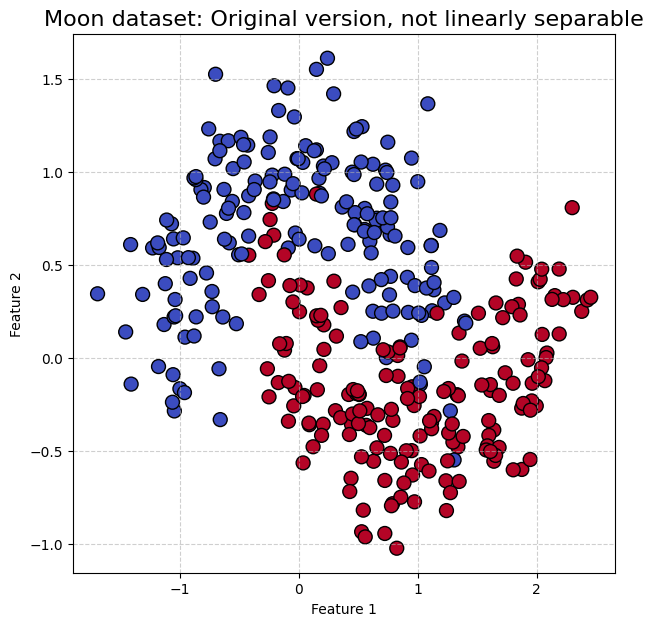

In [59]:
X_np, y_np = make_moons(n_samples=350, noise=0.25, random_state=36)
X = torch.from_numpy(X_np).float()
y = torch.from_numpy(y_np).float().view(-1, 1)

# plotting
plt.figure(figsize=(7, 7))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='coolwarm', s=100, edgecolors='k')
plt.title('Moon dataset: Original version, not linearly separable', fontsize=16)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
# building a model and training it

In [60]:
class Moon_Solver(nn.Module):
    def __init__(self):
        super(Moon_Solver, self).__init__()
        self.hidden1 = nn.Linear(2, 5)   # 2 inputs → 5 neurons
        self.hidden2 = nn.Linear(5, 3)
        self.hidden3 = nn.Linear(3, 3)
        self.output  = nn.Linear(3, 1)   # 3 → 1 output

    def forward(self, x):
        # Pass through first hidden layer and apply ReLU
        x = F.relu(self.hidden1(x))
        # Pass through second hidden layer and apply ReLU
        x = F.relu(self.hidden2(x))
        x = F.relu(self.hidden3(x))
        # Pass through output layer and apply Sigmoid
        x = torch.sigmoid(self.output(x))
        return x

model = Moon_Solver()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
# training loop
epochs = 200
for epoch in range(epochs):
    y_pred = model(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [200/200], Loss: 0.1424


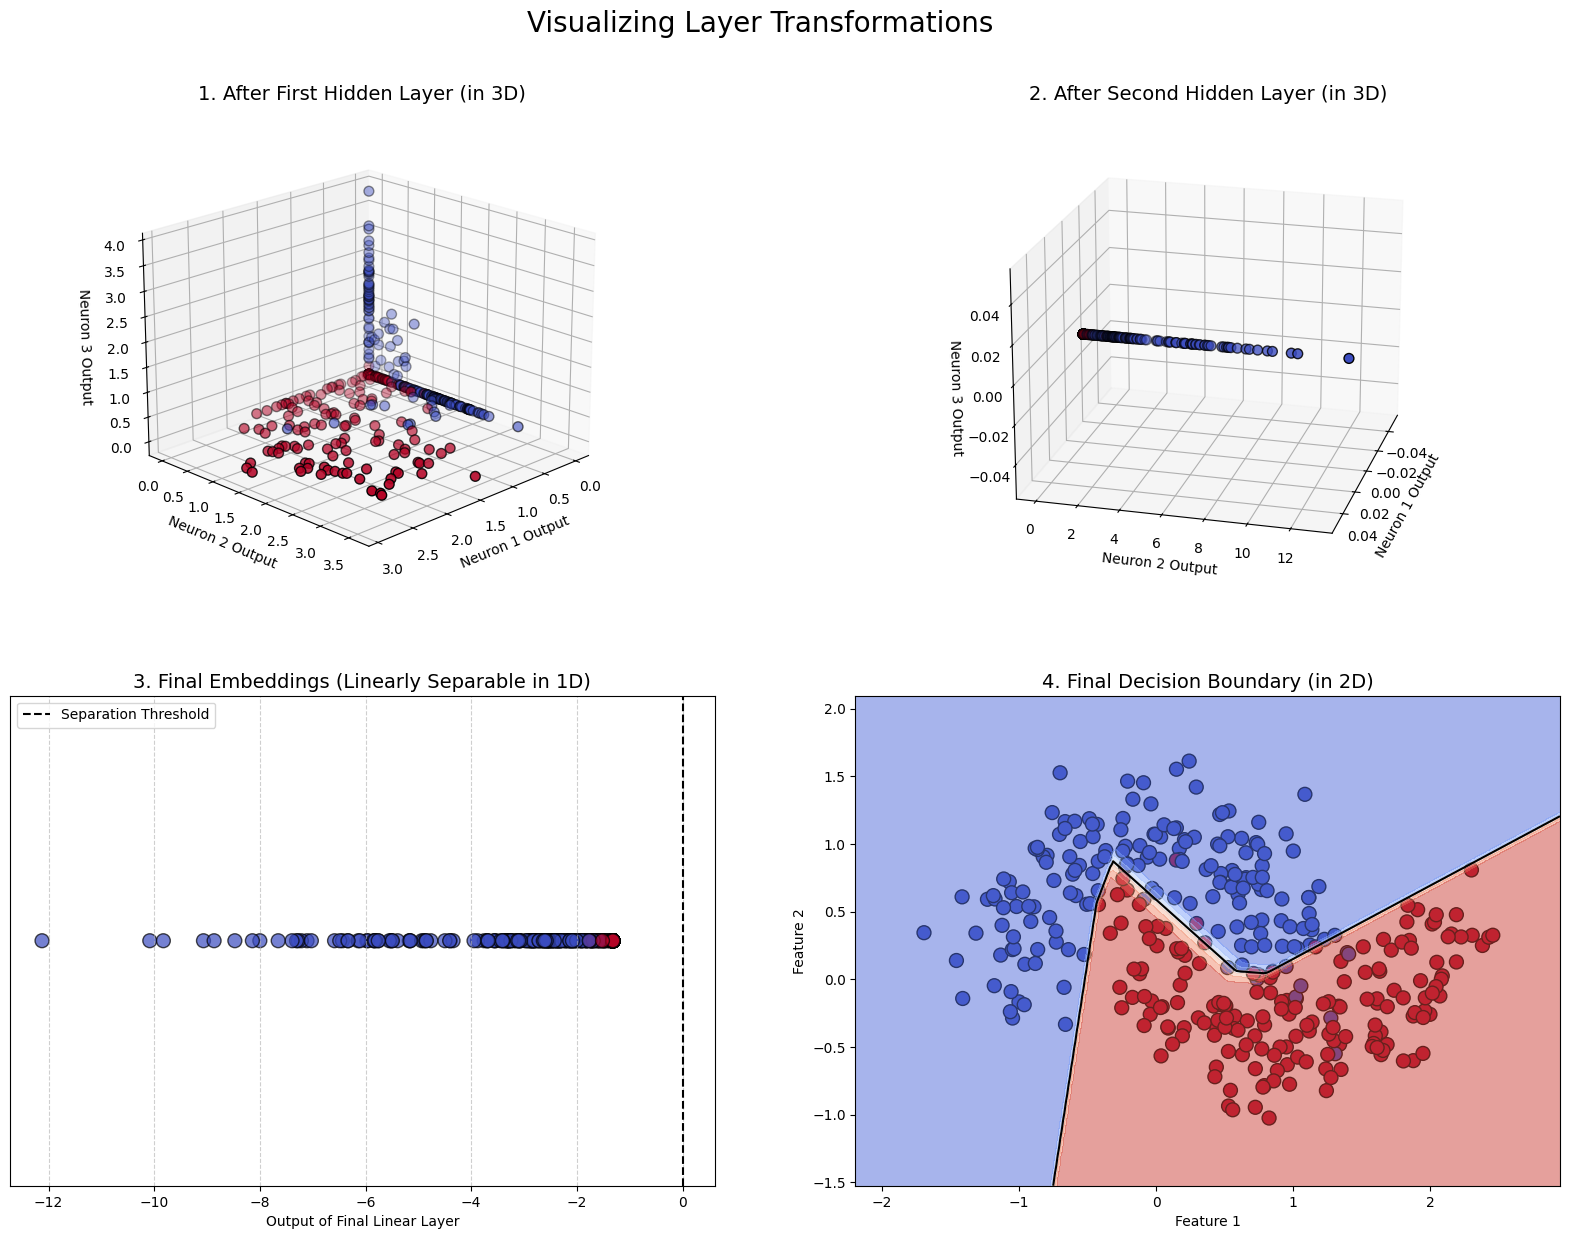

In [61]:
# visualising the output
def get_intermediate_outputs(x):
    out1 = F.relu(model.hidden1(x))
    out2 = F.relu(model.hidden2(out1))
    # Get the raw linear output before the final sigmoid activation
    final_linear_out = model.output(out2)
    final_prob_out = torch.sigmoid(final_linear_out)
    return out1, out2, final_linear_out, final_prob_out

# Get the outputs for our dataset
with torch.no_grad():
    h1_out, h2_out, final_embeddings, _ = get_intermediate_outputs(X)
    h1_out_np = h1_out.numpy()
    h2_out_np = h2_out.numpy()
    final_embeddings_np = final_embeddings.numpy()

# Create plots
fig = plt.figure(figsize=(20, 14))
fig.suptitle("Visualizing Layer Transformations", fontsize=20, y=0.95)

# Plot 1: After 1st Hidden Layer (3D View)
ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(h1_out_np[:, 0], h1_out_np[:, 1], h1_out_np[:, 2], c=y_np, cmap='coolwarm', s=50, edgecolors='k')
ax1.set_title("1. After First Hidden Layer (in 3D)", fontsize=14)
ax1.set_xlabel("Neuron 1 Output")
ax1.set_ylabel("Neuron 2 Output")
ax1.set_zlabel("Neuron 3 Output")
ax1.view_init(elev=20, azim=45) # Set a nice viewing angle

# Plot 2: After 2nd Hidden Layer (3D View)
ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(h2_out_np[:, 0], h2_out_np[:, 1], h2_out_np[:, 2], c=y_np, cmap='coolwarm', s=50, edgecolors='k')
ax2.set_title("2. After Second Hidden Layer (in 3D)", fontsize=14)
ax2.set_xlabel("Neuron 1 Output")
ax2.set_ylabel("Neuron 2 Output")
ax2.set_zlabel("Neuron 3 Output")
ax2.view_init(elev=20, azim=15) # Set a different viewing angle

# Plot 3: The Final Embeddings, projected to 1D
ax3 = fig.add_subplot(223)
ax3.scatter(final_embeddings_np, np.zeros_like(final_embeddings_np), c=y_np, cmap='coolwarm', s=100, edgecolors='k', alpha=0.7)
ax3.axvline(0, color='black', linestyle='--', label='Separation Threshold')
ax3.set_title("3. Final Embeddings (Linearly Separable in 1D)", fontsize=14)
ax3.set_xlabel("Output of Final Linear Layer")
ax3.set_yticks([]) # Hide y-axis ticks for clarity
ax3.grid(True, axis='x', linestyle='--', alpha=0.6)
ax3.legend()


# Plot 4: The Final Decision Boundary in the Original 2D Space
ax4 = fig.add_subplot(224)
ax4.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='coolwarm', s=100, edgecolors='k')
ax4.set_title("4. Final Decision Boundary (in 2D)", fontsize=14)
ax4.set_xlabel("Feature 1")
ax4.set_ylabel("Feature 2")

# Create mesh grid for the decision boundary
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

grid_tensor = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()

# Get model predictions on the grid
model.eval()
with torch.no_grad():
    Z = model(grid_tensor).numpy().reshape(xx.shape)

ax4.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.5)
ax4.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='-')

plt.show()